<a href="https://colab.research.google.com/github/ruthsimon-gif/175finalproject/blob/main/Experiment_1BE_175_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Should we apply logistic regression to all data, or can we combine two types of regression, since some variables are not binary. Do we need to use PLSR to assign the target variables as Y?

The target variables are "Hinselmann", "Schiller", "Cytology",
"Biopsy." Dx columns correspond to previous diagnoses of conditions that may not necessarily align with the current state of the patient. For example: a patient might have a previous diagnosis of cervical cancer but not a current abnormal biopsy result.



---



In [1]:
!pip install imbalanced-learn --quiet

In [2]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # replaces sklearn Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    auc, precision_recall_curve
)
import warnings
warnings.filterwarnings("ignore")

In [3]:
#import required libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

import matplotlib.pyplot as plt

In [10]:
# load dataset
# need to load data
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("clean_data.csv")

df.head()

Saving clean_data.csv to clean_data.csv


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:HPV,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0,0,0,0,0,0,0,0
2,34,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,0.0,0,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,0.0,0,0,0,0,0,0,0,0,0


In [11]:
# =========================
# 4. Choose target variable
# =========================

# Common outcome choice for this dataset:
# Biopsy = 1 means biopsy result indicates cervical cancer risk/diagnosis
target_col = "Biopsy"

# getting rid of
X = df.drop(columns=["Hinselmann", "Schiller", "Citology", "Biopsy"])
y = df[target_col]

print("Class balance:")
print(y.value_counts())
print()

print("Percent positive:")
print(y.mean())

Class balance:
Biopsy
0    803
1     55
Name: count, dtype: int64

Percent positive:
0.0641025641025641


In [12]:
# =========================
# 5. Initial statistics
# =========================

print("Age range:")
print(df["Age"].min(), "to", df["Age"].max())

print("\nPositive biopsy cases:")
print(df["Biopsy"].sum(), "out of", len(df))

print("\nHormonal contraceptives usage:")
print(df["Hormonal Contraceptives"].value_counts(dropna=False))

print("\nSTD history:")
print(df["STDs"].value_counts(dropna=False))

Age range:
13 to 84

Positive biopsy cases:
55 out of 858

Hormonal contraceptives usage:
Hormonal Contraceptives
1.0    589
0.0    269
Name: count, dtype: int64

STD history:
STDs
0.0    779
1.0     79
Name: count, dtype: int64


In [13]:
# =========================
# 6. Train / validation / test split
# =========================

# First split off the test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Then split remaining data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Training size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

print("\nTraining positives:", y_train.sum())
print("Validation positives:", y_val.sum())
print("Test positives:", y_test.sum())

Training size: (514, 30)
Validation size: (172, 30)
Test size: (172, 30)

Training positives: 33
Validation positives: 11
Test positives: 11


In [15]:
# =========================
# 7. SMOTE + Lasso Logistic Regression pipeline
# NOTE: Use ImbPipeline (from imblearn) so SMOTE only runs on training folds
# =========================

lasso_pipeline = ImbPipeline(steps=[
    ("imputer",  SimpleImputer(strategy="median")),
    ("scaler",   StandardScaler()),
    ("smote",    SMOTE(random_state=42)),           # <-- oversamples minority class
    ("model",    LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

# Wider C grid: 0.0001 to 10000 (12 values, log-spaced)
param_grid_lasso = {
    "model__C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 500, 1000, 5000, 10000]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_lasso = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid_lasso,
    scoring="recall",
    cv=cv,
    n_jobs=-1
)
gs_lasso.fit(X_train, y_train)

print("Best C:", gs_lasso.best_params_["model__C"])
print("Best CV recall:", round(gs_lasso.best_score_, 4))

Best C: 1
Best CV recall: 0.4524


In [16]:
# =========================
# 8. Random Forest with SMOTE
# =========================

rf_pipeline = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("smote",   SMOTE(random_state=42)),
    ("model",   RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

param_grid_rf = {
    "model__n_estimators": [100, 300],
    "model__max_depth":    [3, 5, None],
    "model__min_samples_leaf": [1, 5]
}

gs_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring="recall",
    cv=cv,
    n_jobs=-1
)
gs_rf.fit(X_train, y_train)

print("Best RF params:", gs_rf.best_params_)
print("Best CV recall:", round(gs_rf.best_score_, 4))

Best RF params: {'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__n_estimators': 300}
Best CV recall: 0.181


In [17]:
# =========================
# 9. Gradient Boosting with SMOTE
# =========================

gb_pipeline = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("smote",   SMOTE(random_state=42)),
    ("model",   GradientBoostingClassifier(random_state=42))
])

param_grid_gb = {
    "model__n_estimators":  [100, 200],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_depth":     [2, 3]
}

gs_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid_gb,
    scoring="recall",
    cv=cv,
    n_jobs=-1
)
gs_gb.fit(X_train, y_train)

print("Best GB params:", gs_gb.best_params_)
print("Best CV recall:", round(gs_gb.best_score_, 4))

Best GB params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100}
Best CV recall: 0.1238


In [18]:
# =========================
# 10. Reusable threshold tuning function
# =========================

def tune_threshold(model, X_val, y_val, metric="f2"):
    """Returns best threshold, results dataframe, and best val probs."""
    val_probs = model.predict_proba(X_val)[:, 1]
    thresholds = np.arange(0.05, 0.95, 0.01)
    results = []
    for t in thresholds:
        preds = (val_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, preds, labels=[0,1]).ravel()
        results.append({
            "threshold":       t,
            "recall":          recall_score(y_val, preds, zero_division=0),
            "precision":       precision_score(y_val, preds, zero_division=0),
            "f1":              f1_score(y_val, preds, zero_division=0),
            "f2":              fbeta_score(y_val, preds, beta=2, zero_division=0),
            "false_negatives": fn,
            "false_positives": fp,
        })
    df = pd.DataFrame(results)
    best_t = df.sort_values(by=metric, ascending=False).iloc[0]["threshold"]
    return best_t, df, val_probs

# Tune all three models on validation set
best_t_lasso, df_lasso, _ = tune_threshold(gs_lasso.best_estimator_, X_val, y_val)
best_t_rf,    df_rf,    _ = tune_threshold(gs_rf.best_estimator_,    X_val, y_val)
best_t_gb,    df_gb,    _ = tune_threshold(gs_gb.best_estimator_,    X_val, y_val)

print(f"Best threshold — Lasso: {best_t_lasso:.2f}  |  RF: {best_t_rf:.2f}  |  GB: {best_t_gb:.2f}")

Best threshold — Lasso: 0.37  |  RF: 0.33  |  GB: 0.27


In [19]:
# =========================
# 11. Final test evaluation — all 3 models
# =========================

def evaluate_model(name, model, X_test, y_test, threshold):
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= threshold).astype(int)
    print(f"\n{'='*50}")
    print(f"  {name}  (threshold = {threshold:.2f})")
    print(f"{'='*50}")
    print(classification_report(y_test, preds, zero_division=0))
    tn, fp, fn, tp = confusion_matrix(y_test, preds, labels=[0,1]).ravel()
    print(f"Confusion matrix:\n  TN={tn}  FP={fp}\n  FN={fn}  TP={tp}")
    print(f"Recall:            {recall_score(y_test, preds, zero_division=0):.4f}")
    print(f"F2 score:          {fbeta_score(y_test, preds, beta=2, zero_division=0):.4f}")
    print(f"ROC-AUC:           {roc_auc_score(y_test, probs):.4f}")
    print(f"Avg Precision:     {average_precision_score(y_test, probs):.4f}")
    return probs

probs_lasso = evaluate_model("Lasso LR + SMOTE",  gs_lasso.best_estimator_, X_test, y_test, best_t_lasso)
probs_rf    = evaluate_model("Random Forest + SMOTE", gs_rf.best_estimator_, X_test, y_test, best_t_rf)
probs_gb    = evaluate_model("Gradient Boosting + SMOTE", gs_gb.best_estimator_, X_test, y_test, best_t_gb)


  Lasso LR + SMOTE  (threshold = 0.37)
              precision    recall  f1-score   support

           0       0.92      0.35      0.51       161
           1       0.05      0.55      0.10        11

    accuracy                           0.37       172
   macro avg       0.49      0.45      0.31       172
weighted avg       0.86      0.37      0.48       172

Confusion matrix:
  TN=57  FP=104
  FN=5  TP=6
Recall:            0.5455
F2 score:          0.1948
ROC-AUC:           0.4636
Avg Precision:     0.0682

  Random Forest + SMOTE  (threshold = 0.33)
              precision    recall  f1-score   support

           0       0.95      0.50      0.65       161
           1       0.08      0.64      0.14        11

    accuracy                           0.51       172
   macro avg       0.52      0.57      0.40       172
weighted avg       0.90      0.51      0.62       172

Confusion matrix:
  TN=80  FP=81
  FN=4  TP=7
Recall:            0.6364
F2 score:          0.2652
ROC-AUC:    

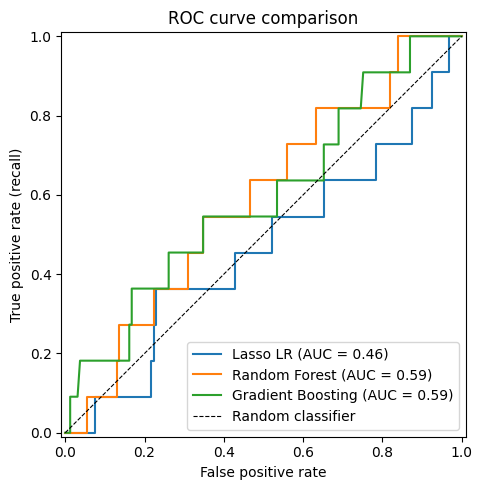

In [20]:
# =========================
# 12. ROC curves — all 3 models
# =========================

fig, ax = plt.subplots(figsize=(7, 5))

for name, probs in [("Lasso LR", probs_lasso),
                    ("Random Forest", probs_rf),
                    ("Gradient Boosting", probs_gb)]:
    RocCurveDisplay.from_predictions(y_test, probs, name=name, ax=ax)

ax.plot([0,1], [0,1], "k--", linewidth=0.8, label="Random classifier")
ax.set_title("ROC curve comparison")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate (recall)")
ax.legend()
plt.tight_layout()
plt.show()

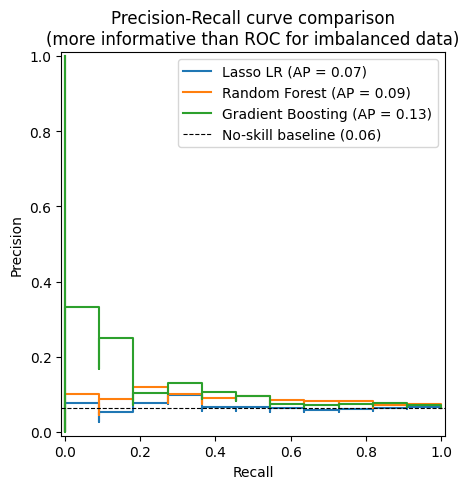

In [21]:
# =========================
# 13. Precision-Recall curves (better metric for imbalanced data)
# =========================

fig, ax = plt.subplots(figsize=(7, 5))

for name, probs in [("Lasso LR", probs_lasso),
                    ("Random Forest", probs_rf),
                    ("Gradient Boosting", probs_gb)]:
    PrecisionRecallDisplay.from_predictions(y_test, probs, name=name, ax=ax)

# Baseline = proportion of positives
baseline = y_test.mean()
ax.axhline(baseline, color="k", linestyle="--", linewidth=0.8,
           label=f"No-skill baseline ({baseline:.2f})")
ax.set_title("Precision-Recall curve comparison\n(more informative than ROC for imbalanced data)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()

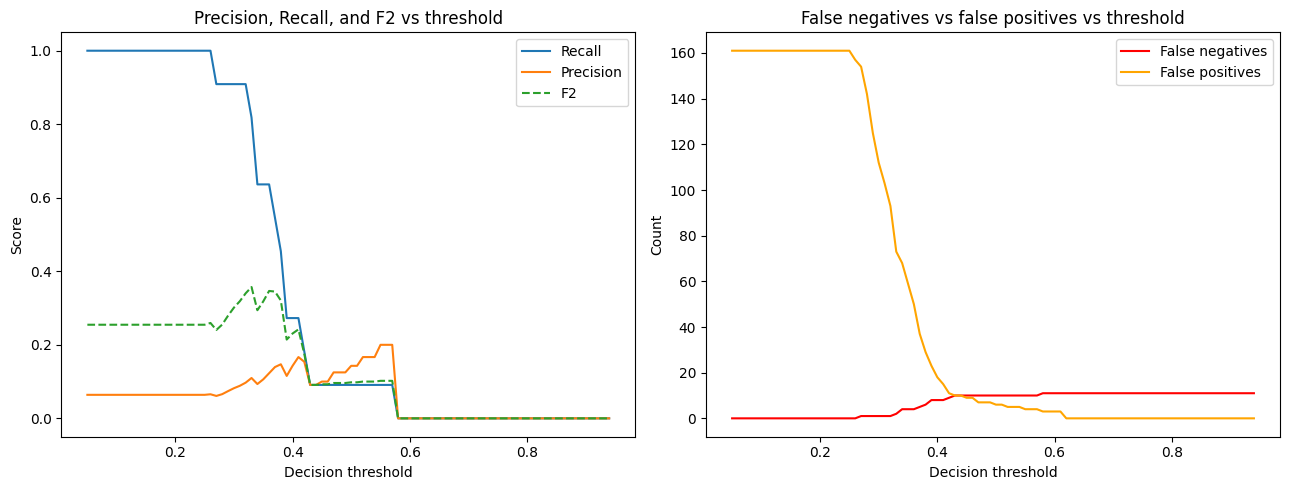

In [22]:
# =========================
# 14. Threshold analysis plot — pick your best model here
# =========================

best_df = df_rf   # swap to df_lasso or df_gb if those win

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(best_df["threshold"], best_df["recall"],    label="Recall")
axes[0].plot(best_df["threshold"], best_df["precision"], label="Precision")
axes[0].plot(best_df["threshold"], best_df["f2"],        label="F2", linestyle="--")
axes[0].set_xlabel("Decision threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision, Recall, and F2 vs threshold")
axes[0].legend()

axes[1].plot(best_df["threshold"], best_df["false_negatives"], label="False negatives", color="red")
axes[1].plot(best_df["threshold"], best_df["false_positives"], label="False positives", color="orange")
axes[1].set_xlabel("Decision threshold")
axes[1].set_ylabel("Count")
axes[1].set_title("False negatives vs false positives vs threshold")
axes[1].legend()

plt.tight_layout()
plt.show()

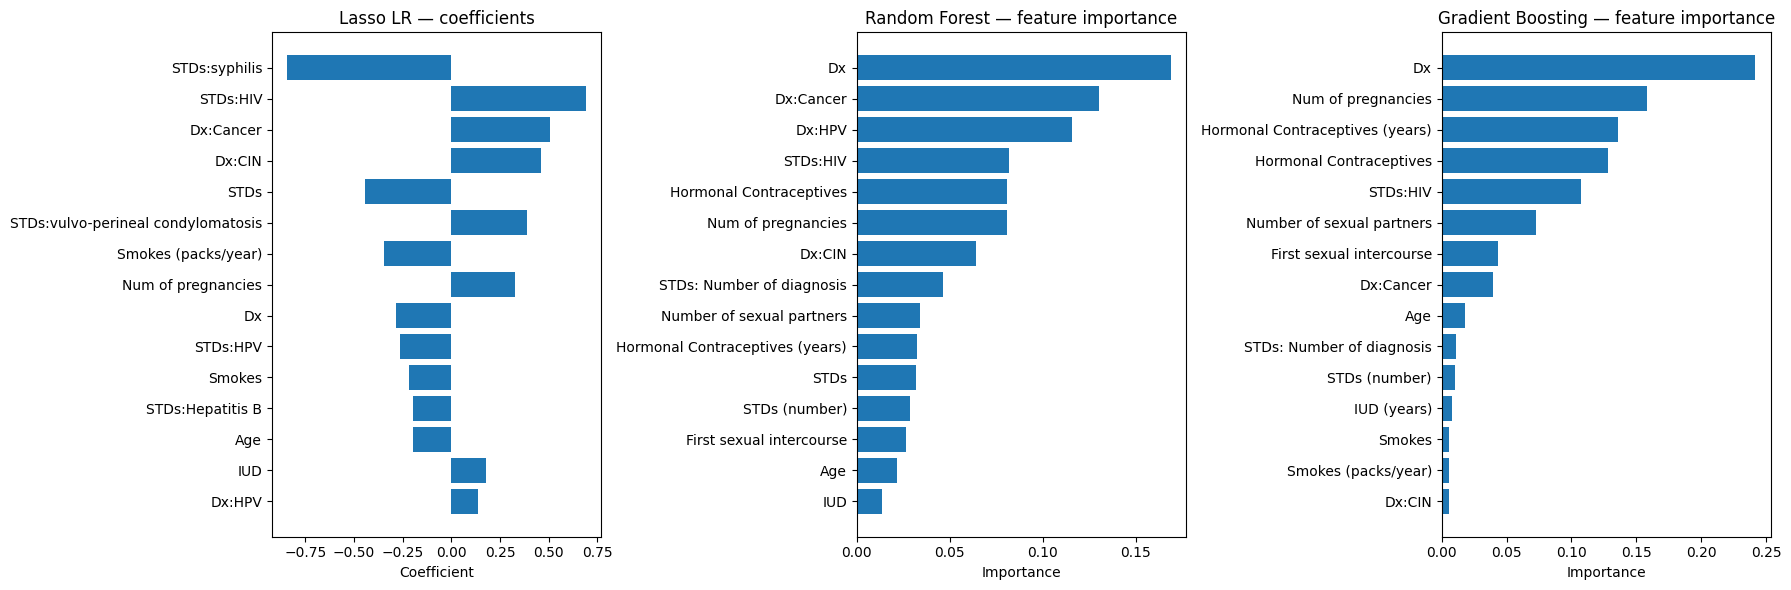

In [23]:
# =========================
# 15. Feature importance — Lasso coefficients + RF/GB importances
# =========================

feature_names = X.columns

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Lasso: coefficients
coefs = gs_lasso.best_estimator_.named_steps["model"].coef_[0]
lasso_df = pd.DataFrame({"feature": feature_names, "importance": coefs}) \
             .reindex(pd.Series(coefs).abs().sort_values(ascending=False).index)
top = lasso_df.head(15)
axes[0].barh(top["feature"], top["importance"])
axes[0].invert_yaxis()
axes[0].set_title("Lasso LR — coefficients")
axes[0].set_xlabel("Coefficient")

# Random Forest: feature importances
rf_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": gs_rf.best_estimator_.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)
axes[1].barh(rf_imp["feature"].head(15), rf_imp["importance"].head(15))
axes[1].invert_yaxis()
axes[1].set_title("Random Forest — feature importance")
axes[1].set_xlabel("Importance")

# Gradient Boosting: feature importances
gb_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": gs_gb.best_estimator_.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)
axes[2].barh(gb_imp["feature"].head(15), gb_imp["importance"].head(15))
axes[2].invert_yaxis()
axes[2].set_title("Gradient Boosting — feature importance")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [24]:
# =========================
# 16. Multi-target risk tier system
# =========================

# Step 1: Train separate models for all 4 targets
# We will use Gradient Boosting (best performer) for each

from sklearn.calibration import CalibratedClassifierCV

targets = ["Hinselmann", "Schiller", "Citology", "Biopsy"]

# Rebuild X with all 4 targets still in the dataframe
# (assumes df is your original cleaned dataframe)
X_full = df.drop(columns=targets)

# Store best models and thresholds per target
target_models     = {}
target_thresholds = {}

for target in targets:
    y_target = df[target]

    # Train/val/test split (same random state = same patients each time)
    X_t, X_test_t, y_t, y_test_t = train_test_split(
        X_full, y_target, test_size=0.20, random_state=42, stratify=y_target
    )
    X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(
        X_t, y_t, test_size=0.25, random_state=42, stratify=y_t
    )

    # Build GB + SMOTE pipeline
    pipe = ImbPipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("smote",   SMOTE(random_state=42, k_neighbors=min(3, y_train_t.sum()-1))),
        ("model",   GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05,
            max_depth=2, random_state=42
        ))
    ])

    pipe.fit(X_train_t, y_train_t)

    # Tune threshold on validation using F2
    best_t, _, _ = tune_threshold(pipe, X_val_t, y_val_t, metric="f2")

    target_models[target]     = pipe
    target_thresholds[target] = best_t

    print(f"{target}: best threshold = {best_t:.2f}  |  "
          f"val positive rate = {y_val_t.mean():.3f}")

Hinselmann: best threshold = 0.06  |  val positive rate = 0.041
Schiller: best threshold = 0.06  |  val positive rate = 0.087
Citology: best threshold = 0.05  |  val positive rate = 0.052
Biopsy: best threshold = 0.09  |  val positive rate = 0.064


In [25]:
# =========================
# 17. Risk tier assignment
# =========================

def assign_risk_tier(row_probs: dict, thresholds: dict) -> dict:
    """
    row_probs: dict of {target: probability} for one patient
    thresholds: dict of {target: best_threshold}
    Returns: predictions, score, tier label, and recommendation
    """
    predictions = {
        t: int(row_probs[t] >= thresholds[t]) for t in targets
    }

    positive_count = sum(predictions.values())
    biopsy_positive = predictions["Biopsy"] == 1

    # Biopsy alone upgrades to at least High Risk
    if biopsy_positive and positive_count < 3:
        positive_count = 3

    tier_map = {
        0: ("Low risk",      "green",  "Routine screening. Return in 3 years."),
        1: ("Mild risk",     "yellow", "Repeat Pap smear in 6–12 months. Monitor closely."),
        2: ("Moderate risk", "orange", "Colposcopy recommended within 3 months."),
        3: ("High risk",     "red",    "Colposcopy and biopsy strongly recommended. "
                                       "Refer to gynecologic oncologist."),
        4: ("Critical",      "red",    "Urgent referral to oncology. "
                                       "Likely requires immediate further workup.")
    }

    tier_label, color, recommendation = tier_map[positive_count]

    return {
        "predictions":      predictions,
        "positive_count":   positive_count,
        "biopsy_positive":  biopsy_positive,
        "tier":             tier_label,
        "recommendation":   recommendation
    }


def score_patient(patient_features: pd.DataFrame) -> pd.DataFrame:
    """
    Score a dataframe of patients and return a results table.
    patient_features: rows of patients, same columns as X_full
    """
    results = []

    for idx, row in patient_features.iterrows():
        row_df = pd.DataFrame([row])

        row_probs = {
            t: target_models[t].predict_proba(row_df)[0, 1]
            for t in targets
        }

        result = assign_risk_tier(row_probs, target_thresholds)
        result["patient_id"] = idx
        result["p_hinselmann"] = round(row_probs["Hinselmann"], 3)
        result["p_schiller"]   = round(row_probs["Schiller"],   3)
        result["p_cytology"]   = round(row_probs["Citology"],   3)
        result["p_biopsy"]     = round(row_probs["Biopsy"],     3)
        results.append(result)

    df_out = pd.DataFrame(results).set_index("patient_id")
    return df_out[[
        "p_hinselmann", "p_schiller", "p_cytology", "p_biopsy",
        "positive_count", "biopsy_positive", "tier", "recommendation"
    ]]

Risk tier distribution in test set:
tier
Critical         77
High risk        46
Moderate risk    42
Mild risk         7
Name: count, dtype: int64

            p_biopsy           tier                                                                recommendation
patient_id                                                                                                       
581            0.126       Critical        Urgent referral to oncology. Likely requires immediate further workup.
505            0.288       Critical        Urgent referral to oncology. Likely requires immediate further workup.
77             0.058      Mild risk                             Repeat Pap smear in 6–12 months. Monitor closely.
695            0.237       Critical        Urgent referral to oncology. Likely requires immediate further workup.
729            0.103      High risk  Colposcopy and biopsy strongly recommended. Refer to gynecologic oncologist.
447            0.059  Moderate risk                   

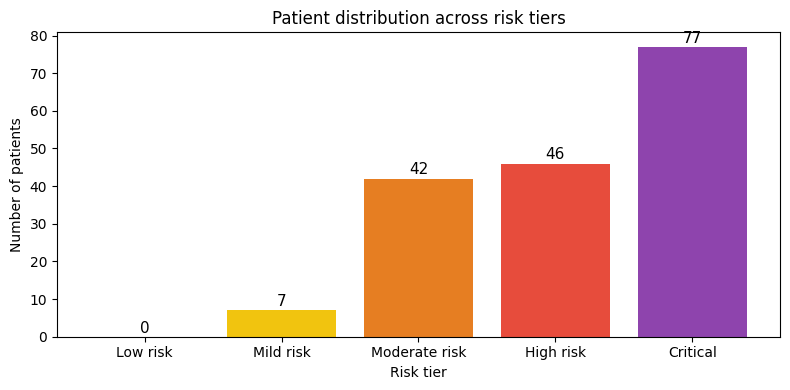

In [26]:
# =========================
# 18. Score all test patients and show tier distribution
# =========================

# Use the original test split (Biopsy target, same random_state=42)
# X_test was defined earlier in your notebook
scored = score_patient(X_test)

print("Risk tier distribution in test set:")
print(scored["tier"].value_counts())
print()
print(scored[["p_biopsy", "tier", "recommendation"]].head(20).to_string())

# Tier distribution plot
tier_order  = ["Low risk", "Mild risk", "Moderate risk", "High risk", "Critical"]
tier_colors = ["#2ecc71",  "#f1c40f",   "#e67e22",        "#e74c3c",   "#8e44ad"]
tier_counts = scored["tier"].value_counts().reindex(tier_order, fill_value=0)

plt.figure(figsize=(8, 4))
bars = plt.bar(tier_counts.index, tier_counts.values, color=tier_colors)
plt.xlabel("Risk tier")
plt.ylabel("Number of patients")
plt.title("Patient distribution across risk tiers")
for bar, count in zip(bars, tier_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3, str(count),
             ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()

In [27]:
# =========================
# 19. Validate: did high-risk tiers actually have positive biopsies?
# =========================

# y_test is the true Biopsy labels from your earlier split
scored["true_biopsy"] = y_test.values

print("Tier vs true biopsy outcome:")
print(pd.crosstab(
    scored["tier"],
    scored["true_biopsy"],
    rownames=["Predicted tier"],
    colnames=["True biopsy"],
    margins=True
))

# What % of true positives ended up in High risk or Critical?
high_risk_patients = scored[scored["tier"].isin(["High risk", "Critical"])]
capture_rate = high_risk_patients["true_biopsy"].sum() / y_test.sum()
print(f"\nCapture rate: {capture_rate:.1%} of true biopsy-positive patients "
      f"were placed in High risk or Critical tier")

Tier vs true biopsy outcome:
True biopsy       0   1  All
Predicted tier              
Critical         72   5   77
High risk        40   6   46
Mild risk         7   0    7
Moderate risk    42   0   42
All             161  11  172

Capture rate: 100.0% of true biopsy-positive patients were placed in High risk or Critical tier


In [28]:
# =========================
# 20. Build multi-class ordinal target
# =========================

# Priority-weighted scoring:
# Biopsy is most invasive → worth 3 points alone to jump straight to class 4
# Hinselmann + Schiller are visual/exam tests → worth 1 point each
# Cytology (Pap smear) → worth 1 point
# Combinations determine the class

def build_risk_class(row):
    biopsy     = row["Biopsy"]
    cytology   = row["Citology"]
    hinselmann = row["Hinselmann"]
    schiller   = row["Schiller"]

    if biopsy == 1:
        return 4   # Urgent oncology referral — biopsy overrides everything

    positive_count = hinselmann + schiller + cytology

    if positive_count == 0:
        return 0   # Routine screening
    elif cytology == 1 and hinselmann == 0 and schiller == 0:
        return 1   # Pap smear concern only → repeat cytology
    elif positive_count == 1:
        return 2   # Single visual test positive → colposcopy
    else:
        return 3   # Multiple tests positive → colposcopy + biopsy referral

df["risk_class"] = df.apply(build_risk_class, axis=1)

print("Risk class distribution:")
print(df["risk_class"].value_counts().sort_index())
print()

label_map = {
    0: "Routine screening",
    1: "Repeat Pap smear (6–12 months)",
    2: "Colposcopy recommended",
    3: "Colposcopy + biopsy referral",
    4: "Urgent oncology referral"
}

for k, v in label_map.items():
    count = (df["risk_class"] == k).sum()
    print(f"  Class {k} — {v}: {count} patients")

Risk class distribution:
risk_class
0    756
1     20
2     15
3     12
4     55
Name: count, dtype: int64

  Class 0 — Routine screening: 756 patients
  Class 1 — Repeat Pap smear (6–12 months): 20 patients
  Class 2 — Colposcopy recommended: 15 patients
  Class 3 — Colposcopy + biopsy referral: 12 patients
  Class 4 — Urgent oncology referral: 55 patients


In [29]:
# =========================
# 21. Split for multi-class model
# =========================

X_mc = df.drop(columns=targets + ["risk_class"])
y_mc = df["risk_class"]

X_temp_mc, X_test_mc, y_temp_mc, y_test_mc = train_test_split(
    X_mc, y_mc,
    test_size=0.20,
    random_state=42,
    stratify=y_mc
)

X_train_mc, X_val_mc, y_train_mc, y_val_mc = train_test_split(
    X_temp_mc, y_temp_mc,
    test_size=0.25,
    random_state=42,
    stratify=y_temp_mc
)

print("Training size:", X_train_mc.shape)
print("Class distribution in training set:")
print(y_train_mc.value_counts().sort_index())

Training size: (514, 30)
Class distribution in training set:
risk_class
0    453
1     12
2      9
3      7
4     33
Name: count, dtype: int64


In [30]:
# =========================
# 22. Multi-class models with SMOTE
# Note: use SMOTE with k_neighbors safe for small classes
# =========================

from sklearn.multiclass import OneVsRestClassifier
from imblearn.over_sampling import SMOTENC
# Using regular SMOTE since all features are numeric after imputation

# Check minimum class size to set k_neighbors safely
min_class_size = y_train_mc.value_counts().min()
k = max(1, min(5, min_class_size - 1))
print(f"Using k_neighbors={k} for SMOTE based on smallest class size={min_class_size}")

# --- Gradient Boosting (multi-class) ---
gb_mc_pipeline = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("smote",   SMOTE(random_state=42, k_neighbors=k)),
    ("model",   GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# --- Random Forest (multi-class) ---
rf_mc_pipeline = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("smote",   SMOTE(random_state=42, k_neighbors=k)),
    ("model",   RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# --- Lasso LR (multi-class via multinomial) ---
lr_mc_pipeline = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("smote",   SMOTE(random_state=42, k_neighbors=k)),
    ("model",   LogisticRegression(
        penalty="l1",
        solver="saga",        # saga supports l1 + multiclass
        multi_class="multinomial",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

# Train all three
print("\nTraining Gradient Boosting...")
gb_mc_pipeline.fit(X_train_mc, y_train_mc)

print("Training Random Forest...")
rf_mc_pipeline.fit(X_train_mc, y_train_mc)

print("Training Lasso LR...")
lr_mc_pipeline.fit(X_train_mc, y_train_mc)

print("\nAll models trained.")

Using k_neighbors=5 for SMOTE based on smallest class size=7

Training Gradient Boosting...
Training Random Forest...
Training Lasso LR...

All models trained.



  Gradient Boosting — multi-class
                                precision    recall  f1-score   support

             Routine screening       0.89      0.93      0.91       152
Repeat Pap smear (6–12 months)       0.00      0.00      0.00         4
        Colposcopy recommended       0.00      0.00      0.00         3
  Colposcopy + biopsy referral       0.00      0.00      0.00         2
      Urgent oncology referral       0.00      0.00      0.00        11

                      accuracy                           0.83       172
                     macro avg       0.18      0.19      0.18       172
                  weighted avg       0.78      0.83      0.80       172



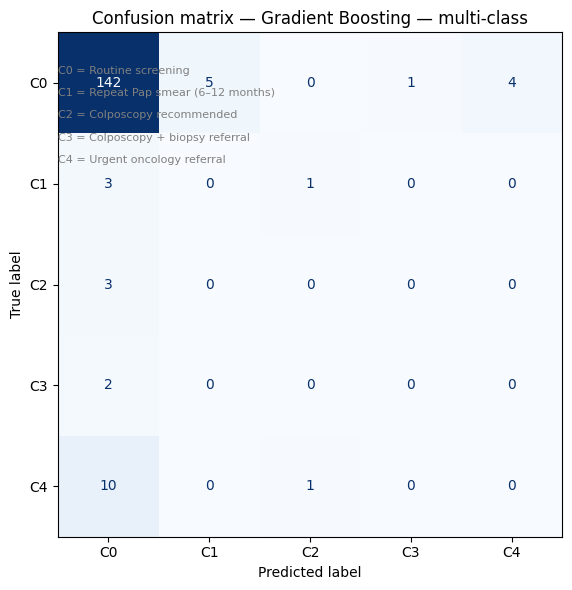


  Random Forest — multi-class
                                precision    recall  f1-score   support

             Routine screening       0.89      0.95      0.92       152
Repeat Pap smear (6–12 months)       0.00      0.00      0.00         4
        Colposcopy recommended       0.00      0.00      0.00         3
  Colposcopy + biopsy referral       0.00      0.00      0.00         2
      Urgent oncology referral       0.00      0.00      0.00        11

                      accuracy                           0.84       172
                     macro avg       0.18      0.19      0.18       172
                  weighted avg       0.79      0.84      0.81       172



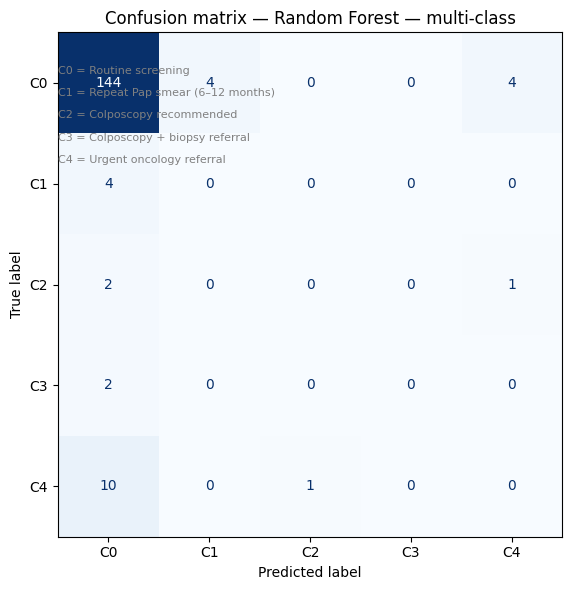


  Lasso LR — multi-class
                                precision    recall  f1-score   support

             Routine screening       0.88      0.38      0.53       152
Repeat Pap smear (6–12 months)       0.03      0.25      0.06         4
        Colposcopy recommended       0.00      0.00      0.00         3
  Colposcopy + biopsy referral       0.00      0.00      0.00         2
      Urgent oncology referral       0.00      0.00      0.00        11

                      accuracy                           0.34       172
                     macro avg       0.18      0.13      0.12       172
                  weighted avg       0.78      0.34      0.47       172



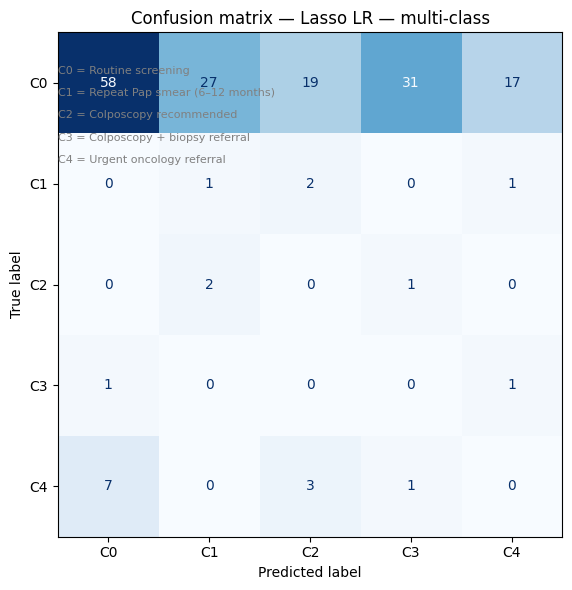

In [31]:
# =========================
# 23. Multi-class evaluation
# =========================

from sklearn.metrics import ConfusionMatrixDisplay

def evaluate_multiclass(name, model, X_test, y_test, label_map):
    preds = model.predict(X_test)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(
        y_test, preds,
        target_names=[label_map[i] for i in sorted(label_map)],
        zero_division=0
    ))

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=[f"C{i}" for i in sorted(label_map)],
        ax=ax,
        colorbar=False,
        cmap="Blues"
    )
    ax.set_title(f"Confusion matrix — {name}")

    # Add class labels as legend below
    for i, label in label_map.items():
        ax.annotate(f"C{i} = {label}",
                    xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, -30 - i*16),
                    textcoords="offset points",
                    fontsize=8, color="gray")
    plt.tight_layout()
    plt.show()

    return preds

preds_gb = evaluate_multiclass(
    "Gradient Boosting — multi-class",
    gb_mc_pipeline, X_test_mc, y_test_mc, label_map
)
preds_rf = evaluate_multiclass(
    "Random Forest — multi-class",
    rf_mc_pipeline, X_test_mc, y_test_mc, label_map
)
preds_lr = evaluate_multiclass(
    "Lasso LR — multi-class",
    lr_mc_pipeline, X_test_mc, y_test_mc, label_map
)

In [32]:
# =========================
# 24. Patient recommendation report
# =========================

recommendation_detail = {
    0: {
        "label":    "Routine screening",
        "urgency":  "Low",
        "action":   "No immediate concern detected. Continue routine cervical "
                    "cancer screening every 3 years.",
        "followup": "Next screening in 3 years or per physician guidance."
    },
    1: {
        "label":    "Repeat Pap smear recommended",
        "urgency":  "Mild",
        "action":   "Cytology result suggests monitoring. A repeat Pap smear "
                    "is recommended within 6–12 months.",
        "followup": "If repeat is abnormal, proceed to colposcopy."
    },
    2: {
        "label":    "Colposcopy recommended",
        "urgency":  "Moderate",
        "action":   "Visual examination findings warrant a colposcopy procedure "
                    "for closer inspection of cervical tissue.",
        "followup": "Schedule colposcopy within 3 months. Bring prior screening records."
    },
    3: {
        "label":    "Colposcopy + biopsy referral",
        "urgency":  "High",
        "action":   "Multiple abnormal indicators detected. Colposcopy with "
                    "possible directed biopsy is strongly recommended.",
        "followup": "Refer to gynecologic specialist within 4–6 weeks."
    },
    4: {
        "label":    "Urgent oncology referral",
        "urgency":  "Critical",
        "action":   "Biopsy findings indicate high cervical cancer risk. "
                    "Urgent referral to gynecologic oncologist is required.",
        "followup": "Contact oncology within 1–2 weeks. Do not delay."
    }
}

urgency_colors = {
    "Low": "\033[92m",       # green
    "Mild": "\033[93m",      # yellow
    "Moderate": "\033[33m",  # orange
    "High": "\033[91m",      # red
    "Critical": "\033[95m"   # magenta
}
RESET = "\033[0m"

def print_patient_report(patient_idx, X_row, model, label_map, rec_detail):
    """Print a readable recommendation report for one patient."""
    row_df    = pd.DataFrame([X_row])
    pred      = model.predict(row_df)[0]
    probs     = model.predict_proba(row_df)[0]
    rec       = rec_detail[pred]
    color     = urgency_colors[rec["urgency"]]

    print(f"\n{'─'*55}")
    print(f"  Patient ID: {patient_idx}")
    print(f"{'─'*55}")
    print(f"  Predicted class:  {color}{pred} — {rec['label']}{RESET}")
    print(f"  Urgency level:    {color}{rec['urgency']}{RESET}")
    print(f"\n  Recommended action:")
    print(f"  {rec['action']}")
    print(f"\n  Follow-up:")
    print(f"  {rec['followup']}")
    print(f"\n  Model confidence per class:")
    for i, p in enumerate(probs):
        bar = "█" * int(p * 30)
        print(f"    C{i} {label_map[i][:28]:<28} {bar} {p:.2%}")
    print(f"{'─'*55}")

# Print reports for first 10 test patients
for i, (idx, row) in enumerate(X_test_mc.head(10).iterrows()):
    print_patient_report(idx, row, gb_mc_pipeline, label_map, recommendation_detail)


───────────────────────────────────────────────────────
  Patient ID: 762
───────────────────────────────────────────────────────
  Predicted class:  0 — Routine screening
  Urgency level:    Low

  Recommended action:
  No immediate concern detected. Continue routine cervical cancer screening every 3 years.

  Follow-up:
  Next screening in 3 years or per physician guidance.

  Model confidence per class:
    C0 Routine screening            █████████████████████████ 86.37%
    C1 Repeat Pap smear (6–12 month ██ 8.01%
    C2 Colposcopy recommended        0.20%
    C3 Colposcopy + biopsy referral  0.35%
    C4 Urgent oncology referral     █ 5.07%
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  Patient ID: 755
───────────────────────────────────────────────────────
  Predicted class:  0 — Routine screening
  Urgency level:    Low

  Recommended action:
  No immediate concern detected. Continue routine cervical cancer scr

In [33]:
# =========================
# 25. Full scored test set with recommendations
# =========================

all_preds  = gb_mc_pipeline.predict(X_test_mc)
all_probs  = gb_mc_pipeline.predict_proba(X_test_mc)

results_mc = pd.DataFrame({
    "true_class":       y_test_mc.values,
    "predicted_class":  all_preds,
    "true_label":       [label_map[c] for c in y_test_mc.values],
    "predicted_label":  [label_map[c] for c in all_preds],
    "confidence":       all_probs.max(axis=1).round(3),
    "correct":          (all_preds == y_test_mc.values)
}, index=X_test_mc.index)

print("Prediction summary:")
print(results_mc["predicted_label"].value_counts())
print(f"\nOverall accuracy: {results_mc['correct'].mean():.1%}")
print(f"\nAccuracy on class 4 (Critical — biopsy positive):")
class4_mask = results_mc["true_class"] == 4
print(f"  {results_mc.loc[class4_mask, 'correct'].mean():.1%} of critical "
      f"patients correctly identified")

results_mc.to_csv("patient_risk_recommendations.csv")
print("\nSaved to patient_risk_recommendations.csv")

Prediction summary:
predicted_label
Routine screening                 160
Repeat Pap smear (6–12 months)      5
Urgent oncology referral            4
Colposcopy recommended              2
Colposcopy + biopsy referral        1
Name: count, dtype: int64

Overall accuracy: 82.6%

Accuracy on class 4 (Critical — biopsy positive):
  0.0% of critical patients correctly identified

Saved to patient_risk_recommendations.csv
